
# Uczenie maszynowe — zajęcia 1
## Principal Component Analysis (PCA) — część 1: skąd biorą się główne składowe?

**Uniwersytet Warmińsko-Mazurski w Olsztynie**  
**Semestr 5, rok akademicki 2026/2027**  
**Prowadzący: mgr inż. Adrian Albrecht**

---

### Cel zajęć

Na tych zajęciach nie korzystamy z gotowej implementacji `sklearn.decomposition.PCA`.

Celem jest zrozumienie, **co PCA faktycznie robi** i samodzielne przejście przez kolejne elementy algorytmu:

1. reprezentację danych jako punktów w przestrzeni wielowymiarowej,
2. centrowanie danych,
3. wariancję i kowariancję,
4. budowę macierzy kowariancji,
5. wartości i wektory własne,
6. uporządkowanie głównych składowych.

Po zajęciach osoba studiująca powinna umieć wyjaśnić, **dlaczego każdy z tych kroków jest wykonywany**.

> **Ważne:** celem ćwiczenia jest samodzielna implementacja i zrozumienie algorytmu. Nie używamy gotowego PCA jako rozwiązania zadania.



## Plan zajęć — 90 minut

| Czas | Temat |
|---:|---|
| 0–10 min | Po co redukować wymiarowość? Intuicja PCA |
| 10–20 min | Zbiór Iris i przestrzeń cech |
| 20–35 min | Średnia i centrowanie danych |
| 35–55 min | Wariancja, kowariancja i macierz kowariancji |
| 55–75 min | Wartości i wektory własne |
| 75–85 min | Sortowanie składowych i udział zmienności |
| 85–90 min | Podsumowanie + zadanie do samodzielnego dokończenia |

Na **drugich zajęciach** wykorzystamy wyznaczone kierunki do projekcji danych i właściwej redukcji:

$$4D \rightarrow 3D \rightarrow 2D$$



# 0. Przygotowanie środowiska

Na dzisiejszych zajęciach wykorzystujemy:

- `numpy` — obliczenia macierzowe,
- `pandas` — wygodne prezentowanie danych,
- `matplotlib` — wizualizacja,
- `sklearn.datasets` — wyłącznie do pobrania gotowego zbioru Iris.

Nie wykorzystujemy klasy `PCA` ze `scikit-learn`.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

np.set_printoptions(precision=4, suppress=True)



# 1. Po co redukować wymiarowość?

Załóżmy, że mamy punkty opisane dwiema cechami:

$
x = [x_1, x_2]
$

Jeżeli obie cechy zmieniają się niemal razem, punkty mogą układać się mniej więcej wzdłuż jednego kierunku.

W takiej sytuacji dwie współrzędne mogą zawierać częściowo **powtarzającą się informację**.

PCA próbuje znaleźć nowy układ współrzędnych, w którym:

- pierwsza oś opisuje możliwie dużo zmienności danych,
- druga oś opisuje możliwie dużo z pozostałej zmienności,
- kolejne osie robią analogicznie to samo.

Nowe osie nazywamy **głównymi składowymi** (*principal components*).

> PCA nie wybiera po prostu kilku istniejących cech.  
> Tworzy **nowe cechy będące kombinacjami liniowymi cech pierwotnych**.


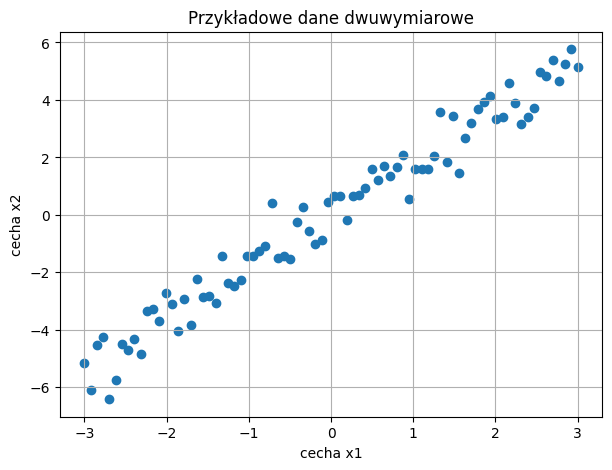

In [2]:

# Prosty przykład danych 2D z wyraźnym dominującym kierunkiem

rng = np.random.default_rng(42)

x1 = np.linspace(-3, 3, 80)
x2 = 1.8 * x1 + rng.normal(0, 0.8, size=len(x1))

example_2d = np.column_stack([x1, x2])

plt.figure(figsize=(7, 5))
plt.scatter(example_2d[:, 0], example_2d[:, 1])
plt.xlabel("cecha x1")
plt.ylabel("cecha x2")
plt.title("Przykładowe dane dwuwymiarowe")
plt.grid()
plt.show()


Patrząc na wykres:

1. Czy obie osie wydają się równie istotne?
2. W którym kierunku punkty są najbardziej rozciągnięte?
3. Czy dałoby się opisać położenie punktów w przybliżeniu jedną nową współrzędną?

To właśnie intuicja stojąca za PCA.

Ważne: **PCA nie zna klas ani etykiet danych**. Analizuje jedynie geometrię i zmienność obserwacji.



# 2. Zbiór Iris

W dalszej części wykorzystamy klasyczny zbiór **Iris**.

Każdy kwiat opisany jest czterema cechami:

1. długość działki kielicha,
2. szerokość działki kielicha,
3. długość płatka,
4. szerokość płatka.

Oznacza to, że pojedyncza obserwacja ma postać:

$x = [x_1, x_2, x_3, x_4]$

i jest punktem w przestrzeni:

$\mathbb{R}^4$

Nie jesteśmy w stanie bezpośrednio narysować przestrzeni czterowymiarowej, dlatego taki zbiór jest dobrym przykładem do redukcji wymiarowości.


In [3]:

iris = load_iris()

X = iris.data
y = iris.target

print("Kształt macierzy X:", X.shape)
print("Liczba obserwacji:", X.shape[0])
print("Liczba cech:", X.shape[1])

print("\nNazwy cech:")
for feature in iris.feature_names:
    print("-", feature)


Kształt macierzy X: (150, 4)
Liczba obserwacji: 150
Liczba cech: 4

Nazwy cech:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


In [4]:

df = pd.DataFrame(X, columns=iris.feature_names)

display(df.head())
display(df.describe().T)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5



## 2.1. Ważne rozróżnienie: wybór dwóch cech to jeszcze nie PCA

Możemy oczywiście narysować dwie wybrane cechy:


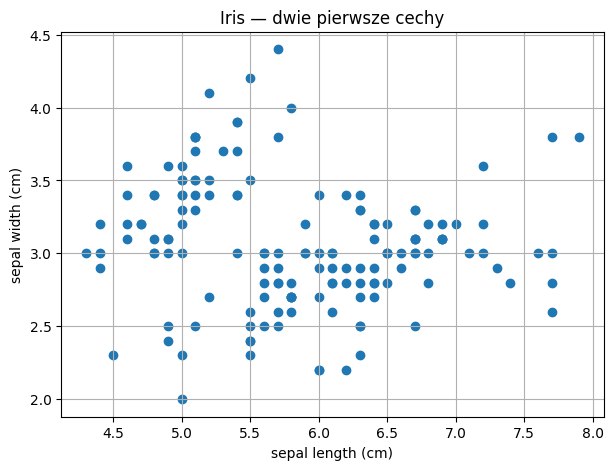

In [5]:

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1])

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Iris — dwie pierwsze cechy")
plt.grid()
plt.show()



Powyższy wykres **nie jest wynikiem PCA**.

Po prostu wybraliśmy:


$x_1,\; x_2$


i odrzuciliśmy:


$x_3,\; x_4$


PCA działa inaczej — tworzy nowe osie na podstawie wszystkich cech.

### Pytania kontrolne

1. Ile wymiarów ma oryginalny zbiór Iris?
2. Czy PCA potrzebuje zmiennej `y`?
3. Czy PCA jest metodą nadzorowaną?
4. Czym różni się wybranie dwóch kolumn od redukcji do dwóch głównych składowych?



# 3. Centrowanie danych

Pierwszym istotnym krokiem PCA jest **centrowanie danych**.

Dla każdej cechy obliczamy średnią:

$\bar{x}_j = \frac{1}{n}\sum_{i=1}^{n}x_{ij}$

a następnie od każdej wartości odejmujemy średnią odpowiedniej cechy:

$x'_{ij} = x_{ij} - \bar{x}_j$

W efekcie każda cecha ma średnią równą w przybliżeniu zero.

Centrowanie **nie zmienia kształtu zbioru**. Przesuwa jedynie cały zbiór tak, aby jego środek znajdował się w początku układu współrzędnych.


In [6]:

mean_vector = np.mean(X, axis=0)

print("Średnia każdej cechy:")
print(mean_vector)


Średnia każdej cechy:
[5.8433 3.0573 3.758  1.1993]


In [7]:

X_centered = X - mean_vector

print("Pierwsze 5 obserwacji po centrowaniu:")
print(X_centered[:5])

print("\nŚrednie po centrowaniu:")
print(np.mean(X_centered, axis=0))


Pierwsze 5 obserwacji po centrowaniu:
[[-0.7433  0.4427 -2.358  -0.9993]
 [-0.9433 -0.0573 -2.358  -0.9993]
 [-1.1433  0.1427 -2.458  -0.9993]
 [-1.2433  0.0427 -2.258  -0.9993]
 [-0.8433  0.5427 -2.358  -0.9993]]

Średnie po centrowaniu:
[-0. -0. -0. -0.]



Wartości po centrowaniu mogą nie być dokładnie równe `0` ze względu na sposób reprezentacji liczb zmiennoprzecinkowych.

Powinny jednak być **bardzo bliskie zeru**.

Sprawdźmy to programowo:


In [8]:

print(
    np.allclose(
        np.mean(X_centered, axis=0),
        np.zeros(X.shape[1])
    )
)


True



## Minićwiczenie 1 — centrowanie

Dane są następujące:

```python
data = np.array([
    [2, 5],
    [4, 7],
    [6, 9]
])
```

### Polecenie

1. Oblicz średnią każdej cechy **ręcznie**.
2. Następnie wykonaj to samo w Pythonie.
3. Wycentruj dane bez używania `StandardScaler`.
4. Sprawdź średnie po centrowaniu.

### Zastanów się

Czy po centrowaniu zmieniły się odległości pomiędzy punktami?


In [9]:

data = np.array([
    [2, 5],
    [4, 7],
    [6, 9]
])

# Przykładowa realizacja po samodzielnym wykonaniu ćwiczenia:

data_mean = np.mean(data, axis=0)
data_centered = data - data_mean

print("Średnia:")
print(data_mean)

print("\nDane po centrowaniu:")
print(data_centered)

print("\nŚrednia po centrowaniu:")
print(np.mean(data_centered, axis=0))


Średnia:
[4. 7.]

Dane po centrowaniu:
[[-2. -2.]
 [ 0.  0.]
 [ 2.  2.]]

Średnia po centrowaniu:
[0. 0.]



# 4. Wariancja

Wariancja opisuje, jak bardzo wartości danej zmiennej są rozproszone wokół średniej.

Dla wariancji próbki:

$Var(X)=
\frac{1}{n-1}
\sum_{i=1}^{n}(x_i-\bar{x})^2$

W PCA interesują nas kierunki, w których dane mają możliwie dużą zmienność.


In [10]:

variances = np.var(X, axis=0, ddof=1)

variance_table = pd.DataFrame({
    "cecha": iris.feature_names,
    "wariancja": variances
})

display(variance_table)


,cecha,wariancja
0,sepal length (cm),0.685694
1,sepal width (cm),0.189979
2,petal length (cm),3.116278
3,petal width (cm),0.581006



Sama wariancja każdej cechy jeszcze nie wystarcza.

PCA musi również wiedzieć, **jak cechy zmieniają się względem siebie**.

Do tego służy kowariancja.



# 5. Kowariancja

Dla dwóch zmiennych \(X\) i \(Y\):

$Cov(X,Y)=
\frac{1}{n-1}
\sum_{i=1}^{n}
(x_i-\bar{x})(y_i-\bar{y})$

Intuicyjnie:

- `Cov(X,Y) > 0` — gdy jedna zmienna rośnie, druga ma tendencję do wzrostu,
- `Cov(X,Y) < 0` — gdy jedna rośnie, druga ma tendencję do spadku,
- `Cov(X,Y) ≈ 0` — brak wyraźnej zależności liniowej.

Warto pamiętać:

$Cov(X,X)=Var(X)$


In [11]:

# Kowariancja dwóch pierwszych cech Iris policzona ręcznie

x = X[:, 0]
z = X[:, 1]

x_centered = x - np.mean(x)
z_centered = z - np.mean(z)

cov_xz_manual = np.sum(x_centered * z_centered) / (len(x) - 1)

print("Kowariancja policzona ręcznie:")
print(cov_xz_manual)

print("\nKowariancja zwrócona przez np.cov:")
print(np.cov(x, z)[0, 1])


Kowariancja policzona ręcznie:
-0.04243400447427292

Kowariancja zwrócona przez np.cov:
-0.042434004474272924



## Minićwiczenie 2 — znak kowariancji

Bez uruchamiania kodu określ, jaki znak kowariancji spodziewasz się dla każdej pary:

### A

```text
x: 1  2  3  4
y: 2  4  6  8
```

### B

```text
x: 1  2  3  4
y: 8  6  4  2
```

### C

```text
x: 1  2  3  4
y: 4  1  4  1
```

Następnie sprawdź odpowiedź za pomocą `np.cov`.


In [12]:

A = np.array([
    [1, 2, 3, 4],
    [2, 4, 6, 8]
])

B = np.array([
    [1, 2, 3, 4],
    [8, 6, 4, 2]
])

C = np.array([
    [1, 2, 3, 4],
    [4, 1, 4, 1]
])

print("A:", np.cov(A)[0, 1])
print("B:", np.cov(B)[0, 1])
print("C:", np.cov(C)[0, 1])


A: 3.333333333333333
B: -3.333333333333333
C: -1.0



# 6. Macierz kowariancji

Jeżeli mamy wiele cech, potrzebujemy kowariancji dla każdej pary.

Dla czterech cech otrzymujemy macierz:

$C=
\begin{bmatrix}
Cov(x_1,x_1) & Cov(x_1,x_2) & Cov(x_1,x_3) & Cov(x_1,x_4)\\
Cov(x_2,x_1) & Cov(x_2,x_2) & Cov(x_2,x_3) & Cov(x_2,x_4)\\
Cov(x_3,x_1) & Cov(x_3,x_2) & Cov(x_3,x_3) & Cov(x_3,x_4)\\
Cov(x_4,x_1) & Cov(x_4,x_2) & Cov(x_4,x_3) & Cov(x_4,x_4)
\end{bmatrix}$

Dla Iris:

$C \in \mathbb{R}^{4\times4}$

Macierz opisuje zależności **pomiędzy cechami**, a nie pomiędzy 150 obserwacjami.


In [13]:

covariance_matrix = np.cov(
    X_centered,
    rowvar=False
)

print("Macierz kowariancji:")
print(covariance_matrix)

print("\nKształt:")
print(covariance_matrix.shape)


Macierz kowariancji:
[[ 0.6857 -0.0424  1.2743  0.5163]
 [-0.0424  0.19   -0.3297 -0.1216]
 [ 1.2743 -0.3297  3.1163  1.2956]
 [ 0.5163 -0.1216  1.2956  0.581 ]]

Kształt:
(4, 4)



## 6.1. Macierz kowariancji bez `np.cov`

Dane są już wycentrowane.

Jeżeli:

$X_c \in \mathbb{R}^{n\times p}$

to macierz kowariancji możemy wyznaczyć jako:

$C=
\frac{1}{n-1}
X_c^T X_c$

Dla Iris:

$X_c \in \mathbb{R}^{150\times4}$

więc:

$X_c^T X_c$

ma wymiar:

$4\times4$

In [14]:

n = X_centered.shape[0]

covariance_manual = (
    X_centered.T @ X_centered
) / (n - 1)

print("Macierz policzona ręcznie:")
print(covariance_manual)

print("\nCzy wynik jest taki sam jak np.cov?")
print(
    np.allclose(
        covariance_manual,
        covariance_matrix
    )
)


Macierz policzona ręcznie:
[[ 0.6857 -0.0424  1.2743  0.5163]
 [-0.0424  0.19   -0.3297 -0.1216]
 [ 1.2743 -0.3297  3.1163  1.2956]
 [ 0.5163 -0.1216  1.2956  0.581 ]]

Czy wynik jest taki sam jak np.cov?
True



## 6.2. Własności macierzy kowariancji

Macierz kowariancji jest **symetryczna**:

$C=C^T$

ponieważ:

$Cov(X,Y)=Cov(Y,X)$

Sprawdźmy:


In [15]:

print(
    np.allclose(
        covariance_matrix,
        covariance_matrix.T
    )
)


True


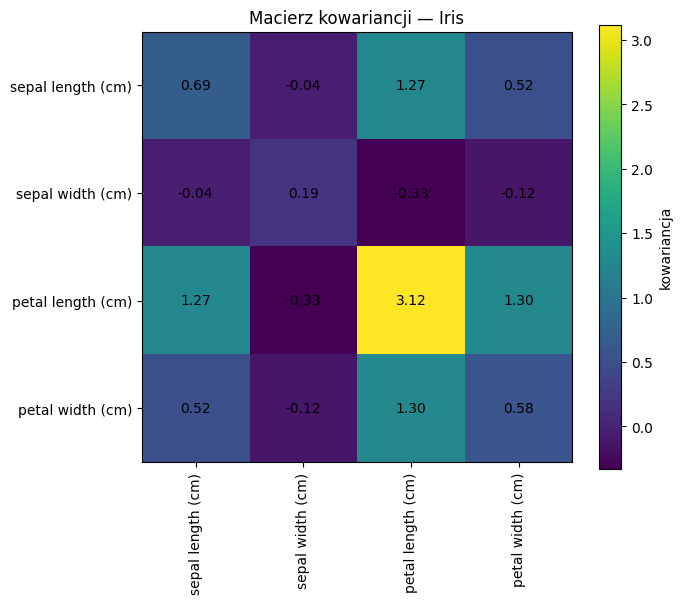

In [16]:

plt.figure(figsize=(7, 6))
plt.imshow(covariance_matrix)
plt.xticks(range(4), iris.feature_names, rotation=90)
plt.yticks(range(4), iris.feature_names)
plt.title("Macierz kowariancji — Iris")

for i in range(covariance_matrix.shape[0]):
    for j in range(covariance_matrix.shape[1]):
        plt.text(
            j,
            i,
            f"{covariance_matrix[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="kowariancja")
plt.tight_layout()
plt.show()



### Pytania kontrolne

1. Dlaczego macierz kowariancji Iris ma rozmiar `4 × 4`, a nie `150 × 150`?
2. Co znajduje się na jej przekątnej?
3. Dlaczego macierz jest symetryczna?
4. Co oznacza duża dodatnia wartość poza przekątną?
5. Czy kowariancja równa zero oznacza całkowity brak jakiejkolwiek zależności między zmiennymi?

Ostatnie pytanie jest szczególnie ważne: kowariancja opisuje przede wszystkim **zależność liniową**.



# 7. Wartości i wektory własne

Mamy już macierz kowariancji.

Teraz chcemy znaleźć kierunki, które opisują strukturę zmienności danych.

Szukamy takich wektorów \(v\), dla których:

$Cv=\lambda v$

gdzie:

- \(C\) — macierz kowariancji,
- \(v\) — wektor własny,
- \($\lambda$\) — odpowiadająca mu wartość własna.

### Interpretacja w PCA

**Wektor własny** opisuje kierunek nowej osi.

**Wartość własna** mówi, ile zmienności danych przypada na ten kierunek.

Dlatego interesują nas przede wszystkim wektory związane z **największymi wartościami własnymi**.



## Dlaczego `np.linalg.eigh`, a nie `np.linalg.eig`?

Macierz kowariancji jest:

- rzeczywista,
- symetryczna.

`np.linalg.eigh()` jest przeznaczone właśnie dla rzeczywistych macierzy symetrycznych (lub zespolonych hermitowskich).

Daje to dodatkową własność ważną dla PCA: otrzymane wektory własne można dobrać jako wzajemnie ortogonalne.


In [17]:

eigenvalues, eigenvectors = np.linalg.eigh(
    covariance_matrix
)

print("Wartości własne zwrócone przez np.linalg.eigh:")
print(eigenvalues)

print("\nMacierz wektorów własnych:")
print(eigenvectors)

print("\nKształt macierzy wektorów własnych:")
print(eigenvectors.shape)


Wartości własne zwrócone przez np.linalg.eigh:
[0.0238 0.0782 0.2427 4.2282]

Macierz wektorów własnych:
[[ 0.3155  0.582   0.6566 -0.3614]
 [-0.3197 -0.5979  0.7302  0.0845]
 [-0.4798 -0.0762 -0.1734 -0.8567]
 [ 0.7537 -0.5458 -0.0755 -0.3583]]

Kształt macierzy wektorów własnych:
(4, 4)



W `numpy` **kolumny** macierzy `eigenvectors` są kolejnymi wektorami własnymi.

Dla czterech cech każdy wektor własny ma cztery współczynniki:

$v=
\begin{bmatrix}
a\\
b\\
c\\
d
\end{bmatrix}$

Taki wektor opisuje nowy kierunek będący kombinacją czterech oryginalnych osi.


In [18]:

first_returned_vector = eigenvectors[:, 0]

print("Pierwszy wektor zwrócony przez funkcję:")
print(first_returned_vector)


Pierwszy wektor zwrócony przez funkcję:
[ 0.3155 -0.3197 -0.4798  0.7537]



## 7.1. Sprawdzenie definicji wektora własnego

Dla pary \(($\lambda, v$)\) powinno zachodzić:

$Cv=\lambda v$

Sprawdźmy to numerycznie dla pierwszej pary zwróconej przez `numpy`.


In [19]:

lambda_0 = eigenvalues[0]
v_0 = eigenvectors[:, 0]

left_side = covariance_matrix @ v_0
right_side = lambda_0 * v_0

print("C @ v:")
print(left_side)

print("\nlambda * v:")
print(right_side)

print("\nCzy wyniki są numerycznie zgodne?")
print(np.allclose(left_side, right_side))


C @ v:
[ 0.0075 -0.0076 -0.0114  0.018 ]

lambda * v:
[ 0.0075 -0.0076 -0.0114  0.018 ]

Czy wyniki są numerycznie zgodne?
True



# 8. Sortowanie głównych składowych

`np.linalg.eigh()` zwraca wartości własne w kolejności rosnącej.

W PCA potrzebujemy kolejności odwrotnej:

$\lambda_1 \ge \lambda_2 \ge \lambda_3 \ge \dots$

Największa wartość własna odpowiada kierunkowi największej zmienności.

Dlatego sortujemy wartości własne malejąco i **w dokładnie tej samej kolejności przestawiamy kolumny macierzy wektorów własnych**.


In [20]:

order = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[order]
eigenvectors_sorted = eigenvectors[:, order]

print("Wartości własne po sortowaniu:")
print(eigenvalues_sorted)

print("\nWektory własne po sortowaniu:")
print(eigenvectors_sorted)


Wartości własne po sortowaniu:
[4.2282 0.2427 0.0782 0.0238]

Wektory własne po sortowaniu:
[[-0.3614  0.6566  0.582   0.3155]
 [ 0.0845  0.7302 -0.5979 -0.3197]
 [-0.8567 -0.1734 -0.0762 -0.4798]
 [-0.3583 -0.0755 -0.5458  0.7537]]



## 8.1. Ile zmienności opisuje każda składowa?

Udział danej składowej możemy policzyć jako:

$r_i=
\frac{\lambda_i}
{\sum_j \lambda_j}$

Wszystkie udziały sumują się do 1.


In [21]:

explained_variance_ratio = (
    eigenvalues_sorted /
    eigenvalues_sorted.sum()
)

variance_ratio_df = pd.DataFrame({
    "składowa": [
        f"PC{i+1}"
        for i in range(len(explained_variance_ratio))
    ],
    "wartość własna": eigenvalues_sorted,
    "udział zmienności": explained_variance_ratio,
    "udział skumulowany": np.cumsum(explained_variance_ratio)
})

display(variance_ratio_df)


,składowa,wartość własna,udział zmienności,udział skumulowany
0,PC1,4.228242,0.924619,0.924619
1,PC2,0.242671,0.053066,0.977685
2,PC3,0.078210,0.017103,0.994788
3,PC4,0.023835,0.005212,1.000000


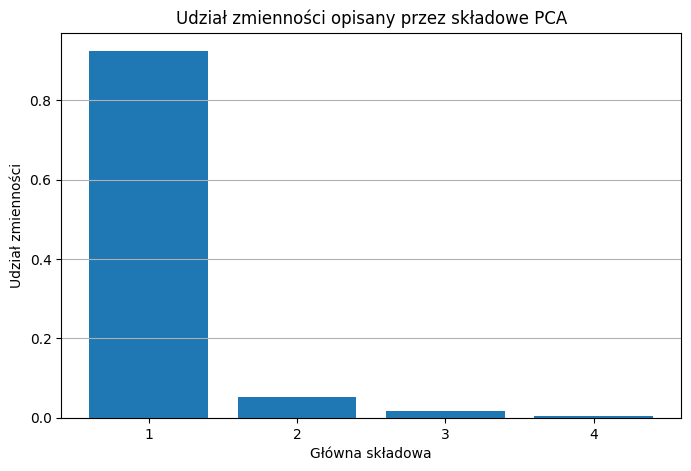

In [22]:

plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio
)

plt.xlabel("Główna składowa")
plt.ylabel("Udział zmienności")
plt.title("Udział zmienności opisany przez składowe PCA")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(axis="y")
plt.show()



### Interpretacja

Jeżeli przykładowo:

$\lambda_1 \gg \lambda_4$

to kierunek odpowiadający pierwszej składowej opisuje znacznie większą część zmienności niż kierunek odpowiadający czwartej składowej.

To jest powód, dla którego możemy później rozważyć odrzucenie części składowych.

Nie wykonujemy jednak jeszcze samej projekcji danych — tym zajmiemy się na kolejnych zajęciach.



# 9. Co dokładnie oznacza główna składowa?

Pierwszy posortowany wektor własny:

```python
eigenvectors_sorted[:, 0]
```

określa kierunek pierwszej głównej składowej.

Dla czterech cech można ją zapisać symbolicznie jako:

$PC_1 =
a_1x_1+
a_2x_2+
a_3x_3+
a_4x_4$

gdzie współczynniki \(a_i\) pochodzą z pierwszego wektora własnego.

PCA **nie wybiera jednej istniejącej kolumny**. Buduje nową zmienną z liniowej kombinacji istniejących cech.


In [23]:

pc1_vector = eigenvectors_sorted[:, 0]

pc1_description = pd.DataFrame({
    "cecha": iris.feature_names,
    "współczynnik PC1": pc1_vector
})

display(pc1_description)


,cecha,współczynnik PC1
0,sepal length (cm),-0.361387
1,sepal width (cm),0.084523
2,petal length (cm),-0.856671
3,petal width (cm),-0.358289



> **Uwaga dotycząca znaku wektora własnego**

Wektor własny \(v\) i wektor \(-v\) opisują ten sam kierunek geometryczny.

Dlatego implementacja PCA może zwrócić np.:

$[0.3,\; -0.2,\; 0.8,\; 0.4]$

a inna poprawna implementacja:

$[-0.3,\; 0.2,\; -0.8,\; -0.4]$

Nie oznacza to, że jedna z nich jest błędna.



# 10. Cały przebieg PCA poznany na dzisiejszych zajęciach

Na razie wykonaliśmy:

```text
DANE
  │
  ▼
średnia każdej cechy
  │
  ▼
centrowanie
  │
  ▼
macierz kowariancji
  │
  ▼
wartości własne + wektory własne
  │
  ▼
sortowanie malejąco według wartości własnych
  │
  ▼
uporządkowane główne składowe
```

Na następnych zajęciach dodamy:

```text
wybór k składowych
  │
  ▼
macierz projekcji
  │
  ▼
projekcja danych
  │
  ▼
dane o mniejszej liczbie wymiarów
```



# 11. Zadanie końcowe

Napisz funkcję:

```python
def pca_components(X):
    ...
```

która dla dowolnej macierzy danych:

1. obliczy średnią każdej cechy,
2. wycentruje dane,
3. obliczy macierz kowariancji **bez używania `np.cov`**,
4. wyznaczy wartości i wektory własne,
5. posortuje je malejąco według wartości własnych,
6. obliczy udział zmienności dla każdej składowej,
7. zwróci wszystkie potrzebne wyniki.

Proponowany format wyniku:

```python
return {
    "mean": ...,
    "X_centered": ...,
    "covariance_matrix": ...,
    "eigenvalues": ...,
    "eigenvectors": ...,
    "explained_variance_ratio": ...
}
```

### Warunek

Właściwa logika PCA ma zostać napisana samodzielnie. Nie korzystamy z gotowej klasy `PCA`.


In [24]:

def pca_components(X):
    # TODO: samodzielna implementacja
    #
    # 1. średnia
    # 2. centrowanie
    # 3. macierz kowariancji
    # 4. wartości i wektory własne
    # 5. sortowanie
    # 6. udział zmienności
    # 7. zwrócenie wyników
    pass



## 11.1. Jak sprawdzić własne rozwiązanie?

Dla zbioru Iris poprawna funkcja powinna spełniać między innymi:

- `mean.shape == (4,)`,
- `X_centered.shape == (150, 4)`,
- `covariance_matrix.shape == (4, 4)`,
- `eigenvalues.shape == (4,)`,
- `eigenvectors.shape == (4, 4)`,
- suma `explained_variance_ratio` powinna być bardzo bliska `1`,
- wartości własne powinny być uporządkowane malejąco,
- macierz kowariancji powinna być symetryczna.

Nie wystarczy jednak, że kod zwraca właściwe liczby.

Trzeba również umieć wyjaśnić, **dlaczego wykonywany jest każdy krok**.



# 12. Pytania podsumowujące

Po zajęciach powinieneś/powinnaś umieć odpowiedzieć na następujące pytania:

1. Co oznacza wymiar danych?
2. Czym różni się wybór dwóch cech od redukcji PCA do dwóch wymiarów?
3. Dlaczego PCA centruje dane?
4. Czym różni się centrowanie od standaryzacji?
5. Co oznacza wariancja?
6. Co oznacza dodatnia i ujemna kowariancja?
7. Co znajduje się na przekątnej macierzy kowariancji?
8. Dlaczego macierz kowariancji jest symetryczna?
9. Dlaczego dla Iris ma rozmiar `4 × 4`?
10. Co oznacza wektor własny macierzy kowariancji?
11. Co oznacza odpowiadająca mu wartość własna?
12. Dlaczego główne składowe sortujemy według wartości własnych?
13. Czy PCA wykorzystuje etykiety klas?
14. Czy znak wektora własnego ma znaczenie dla kierunku głównej składowej?
15. Co będziemy musieli zrobić, aby faktycznie przekształcić dane do przestrzeni dwóch głównych składowych?



# 13. Na następnych zajęciach

Na kolejnych zajęciach dokończymy własną implementację PCA:

1. wybierzemy \(k\) najważniejszych wektorów własnych,
2. zbudujemy macierz projekcji,
3. wykonamy:

$X_{PCA}=X_cW$

4. zredukujemy Iris:
   - z 4 do 3 wymiarów,
   - z 4 do 2 wymiarów,
5. zwizualizujemy wynik,
6. sprawdzimy, jak dużo zmienności zachowujemy,
7. porównamy własny wynik z gotową implementacją wyłącznie w celu weryfikacji poprawności.

---

## Najważniejsza myśl z dzisiejszych zajęć

> **PCA zmienia układ współrzędnych tak, aby pierwsze osie wskazywały kierunki największej zmienności danych.**

Dopiero później możemy zdecydować, że część mniej istotnych osi odrzucamy.
